Proyecto final
joseph mora

> Carga de ibrerías

In [ ]:
import pandas as pd  # Librería para manejar tablas y datos
import numpy as np # Para operaciones matemáticas y generación de datos
from google.colab import files # importar librería para leer archivos locales
import matplotlib.pyplot as plt # realizar gráficas
from sklearn.decomposition import PCA # aplicar PCA
from sklearn.preprocessing import StandardScaler # normalizar variable#s
import seaborn as sns # visualizaciones estadísticas
from sklearn.model_selection import train_test_split # separar data en entrenamiento y validación para modelos
from sklearn.linear_model import LogisticRegression # aplicar modelos de regresión logísitca
from sklearn.metrics import classification_report, confusion_matrix # mostrar matriz de confusión para evaluar modelos
from sklearn.linear_model import LinearRegression # aplicar modelos de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # mostrar métricas para evaluar modelos

> Carga de datos

In [4]:

uploaded = files.upload()

Saving finanzas_personas.xlsx to finanzas_personas.xlsx


In [6]:
import pandas as pd
df_ejemplo = pd.read_excel('finanzas_personas.xlsx')

df_ejemplo.head()

,Edad,Ingreso_Mensual,Horas_Trabajo_Semanal,Gastos_Mensuales,Ahorro_Porcentaje,Nivel_Educativo,Estado_Civil
0,56,3561.08,58,1609.48,13.06,Secundaria,Viudo
1,69,3016.23,59,2355.33,28.12,Postgrado,Casado
2,46,1740.32,54,2463.98,21.18,Secundaria,Viudo
3,32,2257.88,53,2310.26,18.94,Primaria,Casado
4,60,3133.46,43,1892.26,1.50,Universitaria,Viudo


In [8]:
# ============================================================
# ANÁLISIS EXPLORATORIO
# ============================================================

print("Dimensión del dataset:")
print(df_ejemplo.shape)

print("\nColumnas:")
print(df_ejemplo.columns)

print("\nTipos de datos:")
print(df_ejemplo.dtypes)

print("\nResumen estadístico:")
display(df_ejemplo.describe(include="all"))

print("\nValores nulos:")
print(df_ejemplo.isnull().sum())

print("\nDuplicados:")
print(df_ejemplo.duplicated().sum())

Dimensión del dataset:
(500, 7)

Columnas:
Index(['Edad', 'Ingreso_Mensual', 'Horas_Trabajo_Semanal', 'Gastos_Mensuales',
       'Ahorro_Porcentaje', 'Nivel_Educativo', 'Estado_Civil'],
      dtype='object')

Tipos de datos:
Edad                       int64
Ingreso_Mensual          float64
Horas_Trabajo_Semanal      int64
Gastos_Mensuales         float64
Ahorro_Porcentaje        float64
Nivel_Educativo           object
Estado_Civil              object
dtype: object

Resumen estadístico:


,Edad,Ingreso_Mensual,Horas_Trabajo_Semanal,Gastos_Mensuales,Ahorro_Porcentaje,Nivel_Educativo,Estado_Civil
count,500.000000,500.000000,500.000000,500.000000,500.000000,500,500
unique,NaN,NaN,NaN,NaN,NaN,4,4
top,NaN,NaN,NaN,NaN,NaN,Postgrado,Soltero
freq,NaN,NaN,NaN,NaN,NaN,130,134
mean,44.220000,2485.258800,40.214000,1782.698420,14.793440,NaN,NaN
std,15.036082,496.882335,11.316905,420.036414,8.805596,NaN,NaN
min,18.000000,879.370000,20.000000,444.630000,0.010000,NaN,NaN
25%,32.000000,2142.880000,31.000000,1510.280000,7.017500,NaN,NaN
50%,45.000000,2488.745000,40.000000,1792.440000,14.355000,NaN,NaN
75%,57.000000,2814.330000,51.000000,2080.037500,22.645000,NaN,NaN



Valores nulos:
Edad                     0
Ingreso_Mensual          0
Horas_Trabajo_Semanal    0
Gastos_Mensuales         0
Ahorro_Porcentaje        0
Nivel_Educativo          0
Estado_Civil             0
dtype: int64

Duplicados:
0



 Nivel_Educativo


,count
Nivel_Educativo,
Postgrado,130
Primaria,129
Universitaria,125
Secundaria,116


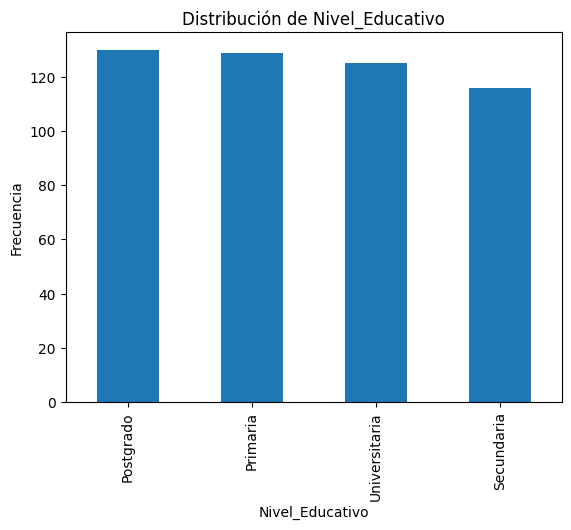


 Estado_Civil


,count
Estado_Civil,
Soltero,134
Divorciado,124
Viudo,123
Casado,119


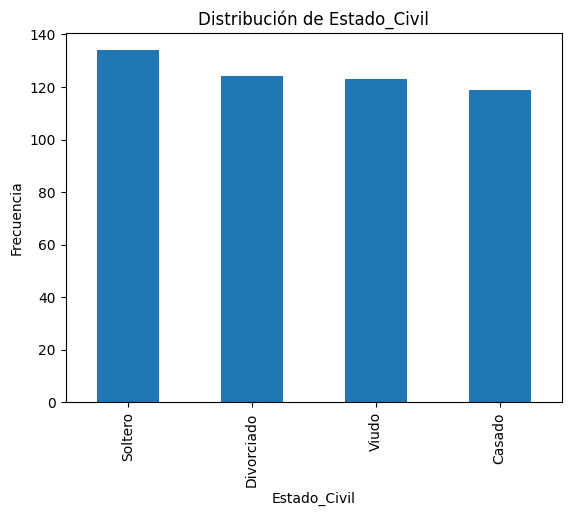

In [11]:
import matplotlib.pyplot as plt # Importar librería para realizar gráficas
# ============================================================
# DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS
# ============================================================

variables_categoricas = ["Nivel_Educativo", "Estado_Civil"]

for variable in variables_categoricas:
    print("\n", variable)
    display(df_ejemplo[variable].value_counts())

    df_ejemplo[variable].value_counts().plot(kind="bar")
    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()

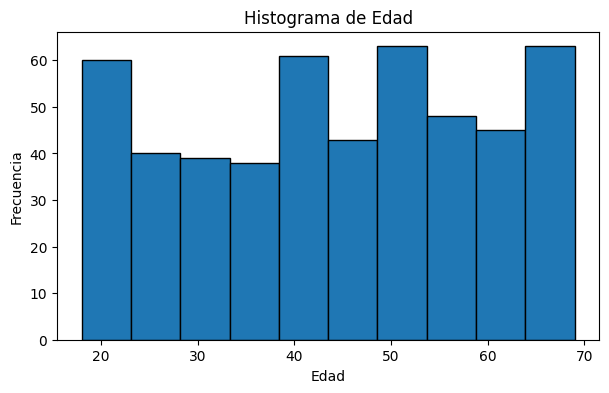

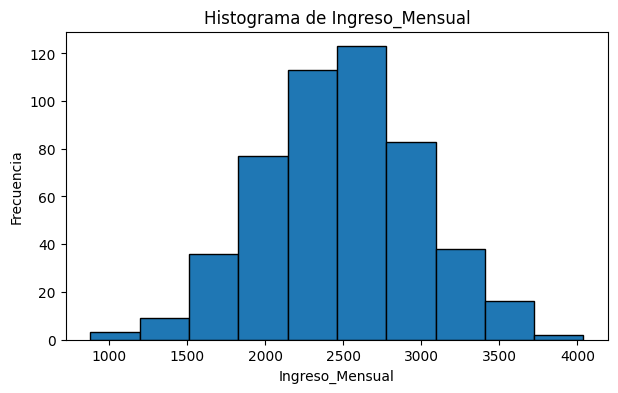

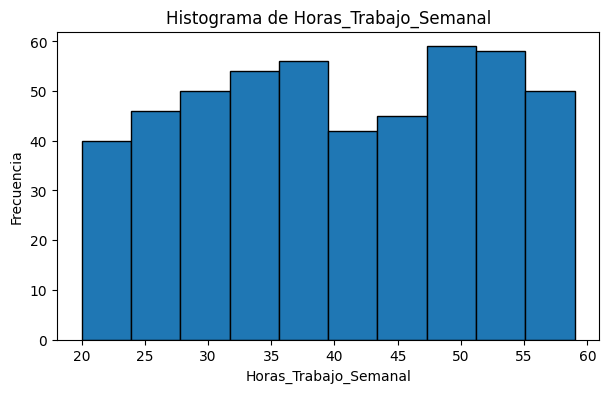

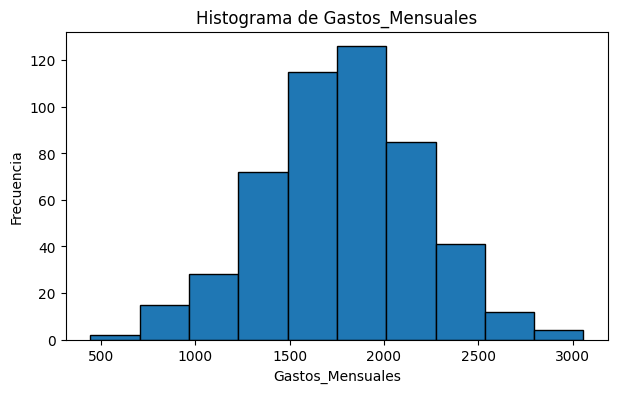

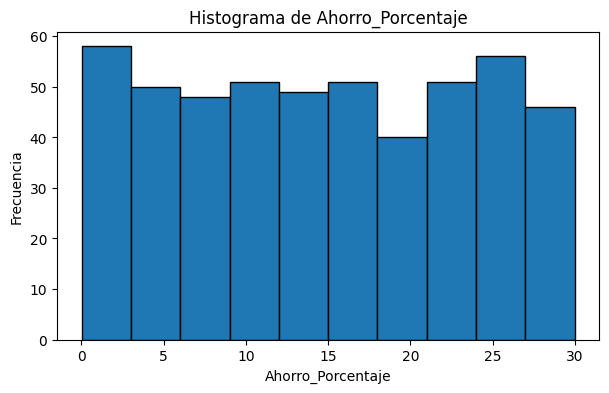

In [13]:
# ============================================================
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# ============================================================

variables_numericas = [
    "Edad",
    "Ingreso_Mensual",
    "Horas_Trabajo_Semanal",
    "Gastos_Mensuales",
    "Ahorro_Porcentaje"
]

for variable in variables_numericas:
    plt.figure(figsize=(7,4))
    plt.hist(df_ejemplo[variable], bins=10, edgecolor="black")
    plt.title(f"Histograma de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()

In [15]:
 # ============================================================
# LIMPIEZA Y PREPARACIÓN DE DATOS
# ============================================================

df_ejemplo = df_ejemplo.drop_duplicates()

for columna in variables_numericas:
    df_ejemplo[columna] = df_ejemplo[columna].fillna(df_ejemplo[columna].mean())

for columna in variables_categoricas:
    df_ejemplo[columna] = df_ejemplo[columna].fillna(df_ejemplo[columna].mode()[0])

print("Valores nulos después de limpieza:")
print(df_ejemplo.isnull().sum())

Valores nulos después de limpieza:
Edad                     0
Ingreso_Mensual          0
Horas_Trabajo_Semanal    0
Gastos_Mensuales         0
Ahorro_Porcentaje        0
Nivel_Educativo          0
Estado_Civil             0
dtype: int64


In [17]:
# ============================================================
# REVISIÓN DE OUTLIERS
# ============================================================

Q1 = df_ejemplo[variables_numericas].quantile(0.25)
Q3 = df_ejemplo[variables_numericas].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_ejemplo[variables_numericas] < (Q1 - 1.5 * IQR)) |
            (df_ejemplo[variables_numericas] > (Q3 + 1.5 * IQR)))

print("Cantidad de outliers por variable:")
print(outliers.sum())

Cantidad de outliers por variable:
Edad                     0
Ingreso_Mensual          2
Horas_Trabajo_Semanal    0
Gastos_Mensuales         2
Ahorro_Porcentaje        0
dtype: int64


,Edad,Ingreso_Mensual,Horas_Trabajo_Semanal,Gastos_Mensuales,Ahorro_Porcentaje
Edad,1.000000,0.021506,-0.040519,-0.003667,-0.010743
Ingreso_Mensual,0.021506,1.000000,0.026539,-0.062164,0.061253
Horas_Trabajo_Semanal,-0.040519,0.026539,1.000000,0.014855,0.037728
Gastos_Mensuales,-0.003667,-0.062164,0.014855,1.000000,-0.034385
Ahorro_Porcentaje,-0.010743,0.061253,0.037728,-0.034385,1.000000


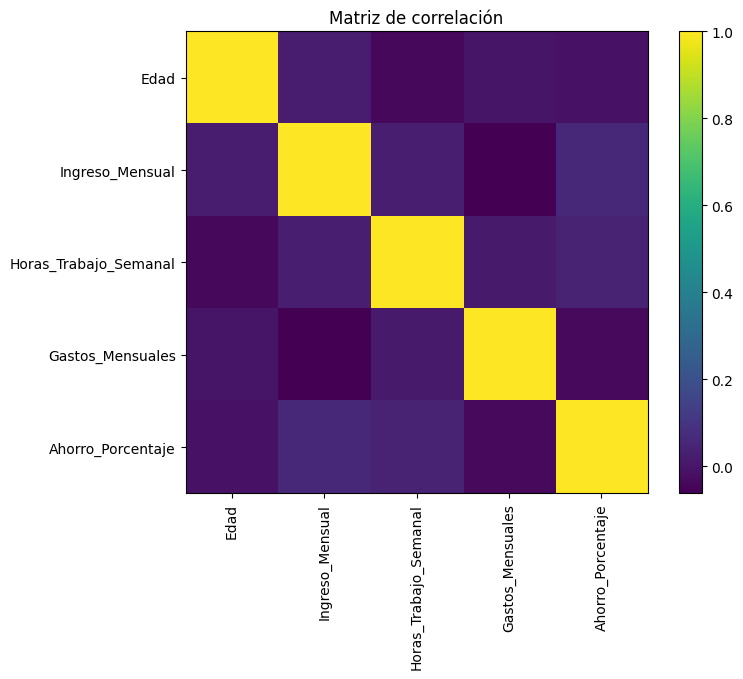

In [19]:
# ============================================================
# ANÁLISIS DE CORRELACIÓN
# ============================================================

correlacion = df_ejemplo[variables_numericas].corr()

display(correlacion)

plt.figure(figsize=(8,6))
plt.imshow(correlacion)
plt.colorbar()
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=90)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)
plt.title("Matriz de correlación")
plt.show()

,Componente_1,Componente_2
0,1.842401,0.069010
1,1.303857,-0.515613
2,-0.946509,-1.652718
3,-0.279522,-1.840346
4,-0.121871,0.898515


Varianza explicada por cada componente:
[0.22287241 0.21014586]
Varianza total explicada:
0.43301827698006395


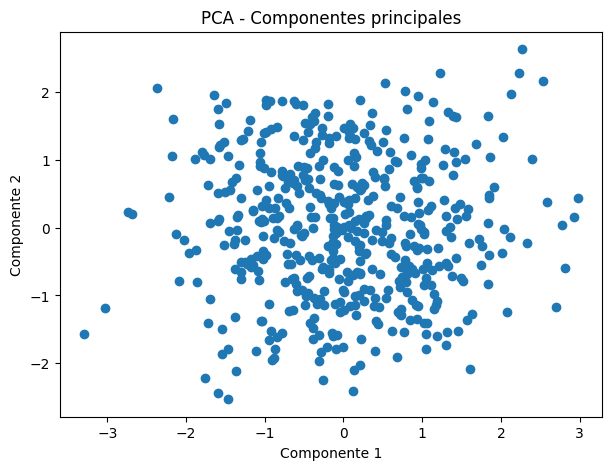

In [23]:
from sklearn.preprocessing import StandardScaler # normalizar variables
from sklearn.decomposition import PCA # aplicar PCA

# ============================================================
# APLICAR PCA
# ============================================================

X = df_ejemplo[variables_numericas]

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_escalado)

df_pca = pd.DataFrame(
    componentes,
    columns=["Componente_1", "Componente_2"]
)

display(df_pca.head())

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("Varianza total explicada:")
print(pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7,5))
plt.scatter(df_pca["Componente_1"], df_pca["Componente_2"])
plt.title("PCA - Componentes principales")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.show()

In [26]:
from sklearn.model_selection import train_test_split # separar data en entrenamiento y validación para modelos
from sklearn.linear_model import LinearRegression # aplicar modelos de regresión lineal

# ============================================================
# APLICAR REGRESIÓN
# Variable objetivo: Gastos_Mensuales
# ============================================================

X = df_ejemplo[[
    "Edad",
    "Ingreso_Mensual",
    "Horas_Trabajo_Semanal",
    "Ahorro_Porcentaje"
]]

y = df_ejemplo["Gastos_Mensuales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Coeficientes del modelo:")
for variable, coef in zip(X.columns, modelo.coef_):
    print(variable, ":", coef)

print("\nIntercepto:")
print(modelo.intercept_)

Coeficientes del modelo:
Edad : -0.48967329302811496
Ingreso_Mensual : -0.061442351949847485
Horas_Trabajo_Semanal : 1.2101435675954895
Ahorro_Porcentaje : -1.9373863410446996

Intercepto:
1941.3761628473762


In [28]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # mostrar métricas para evaluar modelos
import numpy as np # Para operaciones matemáticas y generación de datos

# ============================================================
# ANÁLISIS DE MÉTRICAS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 4))

MAE: 305.45
MSE: 146536.04
RMSE: 382.8
R2: -0.0173


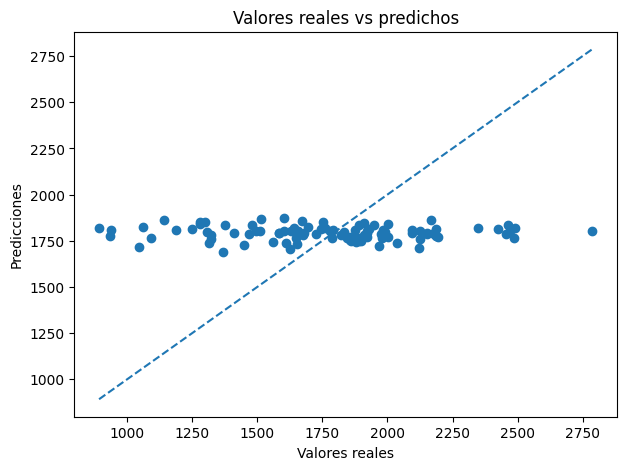

In [29]:
# ============================================================
# GRÁFICO DE VALORES REALES VS PREDICHOS
# ============================================================

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.title("Valores reales vs predichos")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.show()

In [30]:
# ============================================================
# CONCLUSIÓN
# ============================================================

print("""
Durante el proceso de minería de datos se cargó el archivo de finanzas personales,
se realizó un análisis exploratorio para comprender la estructura del dataset,
se verificaron valores nulos, duplicados y posibles outliers.

Posteriormente, se realizó un análisis de correlación entre las variables numéricas.
También se aplicó PCA para reducir la dimensionalidad y observar la información
explicada por los componentes principales.

Finalmente, se aplicó un modelo de regresión lineal para predecir los gastos mensuales
a partir de variables como edad, ingreso mensual, horas de trabajo semanal y porcentaje
de ahorro. Las métricas MAE, MSE, RMSE y R2 permitieron evaluar el desempeño del modelo.
""")


Durante el proceso de minería de datos se cargó el archivo de finanzas personales,
se realizó un análisis exploratorio para comprender la estructura del dataset,
se verificaron valores nulos, duplicados y posibles outliers.

Posteriormente, se realizó un análisis de correlación entre las variables numéricas.
También se aplicó PCA para reducir la dimensionalidad y observar la información
explicada por los componentes principales.

Finalmente, se aplicó un modelo de regresión lineal para predecir los gastos mensuales
a partir de variables como edad, ingreso mensual, horas de trabajo semanal y porcentaje
de ahorro. Las métricas MAE, MSE, RMSE y R2 permitieron evaluar el desempeño del modelo.

